# Clasificación de Modo de Transporte desde GPS con CNN

**Autor:** Mario Carvajal  
**Fecha:** Marzo 2026  
**Framework:** PyTorch · CUDA GPU  
**Dataset:** GeoLife GPS Trajectories — Microsoft Research Asia  
**Resultado:** 77.5% accuracy en 5 modos de transporte  

---

## Problema de Negocio

Las ciudades necesitan saber **cómo se mueven sus ciudadanos** — ¿caminan, usan bicicleta, toman bus, manejan auto o usan tren? Hoy se hace con encuestas costosas que tardan meses y se desactualizan inmediatamente. Este modelo lo resuelve **automáticamente** a partir de datos GPS crudos de celulares — sin sensores adicionales ni encuestas.

## Enfoque Técnico

El pipeline convierte trayectorias GPS en una clasificación de modo de transporte en 4 pasos:

1. **Extraer features cinemáticos** de cada segmento GPS (velocidad, aceleración, cambios de dirección)
2. **Crear ventanas temporales** de tamaño fijo (60 puntos ≈ 1-5 minutos)
3. **Organizar como matriz 2D** (tiempo × features) que la CNN trata como una "imagen"
4. **Clasificar con CNN** en 5 modos: walk, bike, bus, car, train

## Dataset

[GeoLife](https://www.microsoft.com/en-us/download/details.aspx?id=52367) — 17,621 trayectorias GPS recolectadas por 182 usuarios en Beijing (2007-2012). De estos, **69 usuarios** anotaron manualmente su modo de transporte, generando **14,692 etiquetas reales**. Papers publicados con este dataset reportan 83-93% accuracy.

---
## 1. Configuración del Entorno

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from math import radians, sin, cos, sqrt, atan2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch: {torch.__version__}')

Dispositivo: cuda
PyTorch: 2.11.0+cu128


---
## 2. Carga de Datos GeoLife con Etiquetas de Transporte

El dataset contiene 182 usuarios, pero solo **69** tienen archivos `labels.txt` con el modo de transporte anotado. Cada etiqueta especifica un intervalo temporal y el modo usado en ese tramo.

Agrupamos los 11 modos originales en **5 clases** siguiendo la convención de la literatura académica:

| Clase | Modos originales incluidos |
|-------|---------------------------|
| **Walk** | walk, run |
| **Bike** | bike |
| **Bus** | bus |
| **Car** | car, taxi |
| **Train** | train, subway, railway |

Se excluyen modos con muy pocos datos (airplane, boat, motorcycle).

In [ ]:
GEOLIFE_PATH = './Data'  # Ruta al dataset GeoLife descomprimido

# Agrupación de modos de transporte (siguiendo papers publicados)
MODE_MAP = {
    'walk': 'walk', 'run': 'walk',
    'bike': 'bike',
    'bus': 'bus',
    'car': 'car', 'taxi': 'car',
    'train': 'train', 'subway': 'train', 'railway': 'train',
}
MODE_NAMES = ['walk', 'bike', 'bus', 'car', 'train']
MODE_IDS = {name: i for i, name in enumerate(MODE_NAMES)}


def read_plt(filepath):
    """Lee un archivo .plt y retorna DataFrame con lat, lon, alt, datetime."""
    try:
        df = pd.read_csv(filepath, skiprows=6, header=None,
                         names=['lat','lon','_','alt','__','date','time'])
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
        return df[['lat','lon','alt','datetime']].copy()
    except:
        return pd.DataFrame()


def read_labels(filepath):
    """
    Lee labels.txt del GeoLife.
    Formato (tab-separated):
        Start Time\tEnd Time\tTransportation Mode
        2008/11/01 03:59:27\t2008/11/01 04:30:18\ttrain
    """
    labels = []
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    for line in lines[1:]:  # Skip header
        line = line.strip()
        if not line:
            continue
        
        # Intentar split por tab primero (formato oficial)
        parts = line.split('\t')
        
        if len(parts) == 3:
            # Tab-separated: 'start_datetime\tend_datetime\tmode'
            start_str, end_str, mode = parts
        elif len(parts) >= 5:
            # Space-separated fallback: 'date time date time mode'
            start_str = f'{parts[0]} {parts[1]}'
            end_str = f'{parts[2]} {parts[3]}'
            mode = parts[4]
        else:
            # Intentar por espacios
            parts = line.split()
            if len(parts) >= 5:
                start_str = f'{parts[0]} {parts[1]}'
                end_str = f'{parts[2]} {parts[3]}'
                mode = parts[4]
            else:
                continue
        
        mode = mode.strip().lower()
        if mode not in MODE_MAP:
            continue
        
        try:
            start = pd.to_datetime(start_str.strip())
            end = pd.to_datetime(end_str.strip())
            labels.append({'start': start, 'end': end, 'mode': MODE_MAP[mode]})
        except:
            continue
    
    return pd.DataFrame(labels)


def load_labeled_data(geolife_path):
    """
    Carga todos los usuarios con etiquetas.
    Asigna modo de transporte a cada punto GPS usando los intervalos de labels.txt.
    """
    all_segments = []
    user_dirs = sorted(glob.glob(os.path.join(geolife_path, '*')))
    labeled_users = 0
    total_labels = 0
    
    for user_dir in tqdm(user_dirs, desc='Cargando usuarios'):
        if not os.path.isdir(user_dir):
            continue
        labels_file = os.path.join(user_dir, 'labels.txt')
        if not os.path.exists(labels_file):
            continue
        
        labeled_users += 1
        labels_df = read_labels(labels_file)
        if len(labels_df) == 0:
            continue
        total_labels += len(labels_df)
        
        # Leer TODAS las trayectorias de este usuario
        plt_files = sorted(glob.glob(os.path.join(user_dir, 'Trajectory', '*.plt')))
        
        # Concatenar todos los puntos del usuario
        user_points = []
        for plt_file in plt_files:
            pts = read_plt(plt_file)
            if len(pts) > 0:
                user_points.append(pts)
        
        if not user_points:
            continue
        
        all_points = pd.concat(user_points, ignore_index=True)
        all_points = all_points.sort_values('datetime').reset_index(drop=True)
        
        # Para cada etiqueta, extraer el segmento correspondiente
        for _, label_row in labels_df.iterrows():
            mask = (all_points['datetime'] >= label_row['start']) & \
                   (all_points['datetime'] <= label_row['end'])
            segment = all_points[mask].copy()
            
            if len(segment) >= 10:
                segment['mode'] = label_row['mode']
                segment['user'] = os.path.basename(user_dir)
                all_segments.append(segment)
    
    print(f'Usuarios con labels.txt: {labeled_users}')
    print(f'Etiquetas totales leídas: {total_labels}')
    print(f'Segmentos con ≥10 puntos: {len(all_segments)}')
    return all_segments


segments = load_labeled_data(GEOLIFE_PATH)

if len(segments) > 0:
    print(f'\nPuntos totales con etiqueta: {sum(len(s) for s in segments):,}')
    print(f'\nDistribución de segmentos por modo:')
    mode_counts = pd.Series([s['mode'].iloc[0] for s in segments]).value_counts()
    print(mode_counts)
    print(f'\nEjemplo de segmento:')
    print(f'  Modo: {segments[0]["mode"].iloc[0]}')
    print(f'  Puntos: {len(segments[0])}')
    print(segments[0][['lat','lon','datetime']].head())
else:
    print('\n⚠️ No se encontraron segmentos.')
    # Diagnóstico
    print('\nDiagnóstico:')
    labels_files = glob.glob(os.path.join(GEOLIFE_PATH, '*', 'labels.txt'))
    print(f'  Archivos labels.txt encontrados: {len(labels_files)}')
    if labels_files:
        print(f'  Ejemplo: {labels_files[0]}')
        with open(labels_files[0], 'r') as f:
            lines = f.readlines()[:5]
        print('  Primeras líneas:')
        for l in lines:
            print(f'    [{repr(l.strip())}]')

Cargando usuarios: 100%|██████████| 182/182 [01:12<00:00,  2.52it/s]


Usuarios con labels.txt: 69
Etiquetas totales leídas: 14692
Segmentos con ≥10 puntos: 9257

Puntos totales con etiqueta: 5,494,193

Distribución de segmentos por modo:
walk     3837
bus      1831
bike     1562
car      1288
train     739
Name: count, dtype: int64

Ejemplo de segmento:
  Modo: train
  Puntos: 69
              lat         lon            datetime
180198  39.894178  116.318200 2008-03-28 14:54:40
180199  39.894505  116.321132 2008-03-28 14:55:14
180200  39.894953  116.326452 2008-03-28 14:56:13
180201  39.894600  116.332542 2008-03-28 14:57:12
180202  39.889622  116.337040 2008-03-28 14:58:11


---
## 3. Feature Engineering — De Coordenadas GPS a Cinemática

Los datos GPS crudos son solo `(latitud, longitud, timestamp)` — no contienen información directa sobre el modo de transporte. Pero la **física del movimiento** sí lo revela:

| Feature | Fórmula | Qué captura |
|---------|---------|-------------|
| **Distancia** | Haversine entre puntos | Cuánto se movió entre lecturas |
| **Velocidad** | distancia / Δt | Qué tan rápido va (m/s) |
| **Aceleración** | Δvelocidad / Δt | Arranques y frenados |
| **Cambio de dirección** | Δbearing (°) | Giros — caminar es errático, tren es recto |
| **Jerk** | Δaceleración / Δt | Suavidad del movimiento |

Cada modo tiene una **firma cinemática** distintiva que la CNN aprende a reconocer.

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    """Calcula distancia en metros entre dos puntos GPS."""
    R = 6371000  # Radio de la Tierra en metros
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


def compute_bearing(lat1, lon1, lat2, lon2):
    """Calcula dirección (bearing) en grados entre dos puntos."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return bearing % 360


def extract_features(segment):
    """
    Extrae features cinemáticos de un segmento GPS.
    
    Returns:
        DataFrame con columnas: distance, speed, acceleration, bearing_change, jerk
    """
    df = segment.sort_values('datetime').reset_index(drop=True)
    
    # Diferencia temporal en segundos
    dt = df['datetime'].diff().dt.total_seconds().values[1:]
    dt = np.where(dt == 0, 0.1, dt)  # Evitar división por cero
    
    # Distancia entre puntos consecutivos (metros)
    dist = haversine(
        df['lat'].values[:-1], df['lon'].values[:-1],
        df['lat'].values[1:], df['lon'].values[1:]
    )
    
    # Velocidad (m/s)
    speed = dist / dt
    speed = np.clip(speed, 0, 200)  # Cap a 200 m/s (~720 km/h) para outliers
    
    # Aceleración (m/s²)
    accel = np.diff(speed) / dt[1:]
    accel = np.clip(accel, -50, 50)
    accel = np.concatenate([[0], accel])  # Pad primer valor
    
    # Bearing y cambio de bearing
    bearing = compute_bearing(
        df['lat'].values[:-1], df['lon'].values[:-1],
        df['lat'].values[1:], df['lon'].values[1:]
    )
    bearing_change = np.abs(np.diff(bearing))
    bearing_change = np.where(bearing_change > 180, 360 - bearing_change, bearing_change)
    bearing_change = np.concatenate([[0], bearing_change])
    
    # Jerk (cambio de aceleración)
    jerk = np.diff(accel) / dt[1:]
    jerk = np.clip(jerk, -100, 100)
    jerk = np.concatenate([[0], jerk])
    
    return pd.DataFrame({
        'distance': dist,
        'speed': speed,
        'acceleration': accel,
        'bearing_change': bearing_change,
        'jerk': jerk
    })

print('Funciones de feature engineering definidas.')
print('Features: distance, speed, acceleration, bearing_change, jerk')

Funciones de feature engineering definidas.
Features: distance, speed, acceleration, bearing_change, jerk


---
## 4. Creación de Ventanas Temporales

Cada segmento GPS tiene longitud variable (desde 10 hasta miles de puntos). Para alimentar la CNN necesitamos inputs de tamaño fijo.

Dividimos cada segmento en **ventanas deslizantes de 60 puntos** con 50% de solapamiento. Cada ventana cubre aproximadamente 1-5 minutos de movimiento, suficiente para capturar el patrón cinemático del modo de transporte.

Resultado: cada muestra es una **matriz de 60×5** (60 timesteps × 5 features) que la CNN procesa como una "imagen" de 1 canal.

In [ ]:
WINDOW_SIZE = 60   # Puntos por ventana
STRIDE = 30        # Solapamiento del 50%
N_FEATURES = 5     # distance, speed, acceleration, bearing_change, jerk

X_windows = []
y_windows = []

for seg in tqdm(segments, desc='Extrayendo features'):
    mode = seg['mode'].iloc[0]
    if mode not in MODE_IDS:
        continue
    
    feats = extract_features(seg)
    
    if len(feats) < WINDOW_SIZE:
        continue
    
    # Crear ventanas deslizantes
    values = feats.values  # (n_points, 5)
    for start in range(0, len(values) - WINDOW_SIZE + 1, STRIDE):
        window = values[start:start + WINDOW_SIZE]  # (60, 5)
        X_windows.append(window)
        y_windows.append(MODE_IDS[mode])

X_windows = np.array(X_windows, dtype=np.float32)  # (N, 60, 5)
y_windows = np.array(y_windows)

print(f'\nVentanas generadas: {len(X_windows):,}')
print(f'Forma: {X_windows.shape} (muestras × tiempo × features)')
print(f'\nDistribución por modo:')
for i, name in enumerate(MODE_NAMES):
    count = (y_windows == i).sum()
    print(f'  {name}: {count:,} ({count/len(y_windows)*100:.1f}%)')

Extrayendo features: 100%|██████████| 9257/9257 [00:05<00:00, 1780.95it/s]



Ventanas generadas: 169,655
Forma: (169655, 60, 5) (muestras × tiempo × features)

Distribución por modo:
  walk: 48,415 (28.5%)
  bike: 29,658 (17.5%)
  bus: 40,068 (23.6%)
  car: 23,466 (13.8%)
  train: 28,048 (16.5%)


---
## 5. Análisis Exploratorio (EDA)

Antes de entrenar la CNN, visualizamos las diferencias cinemáticas entre modos. Si los features no separan las clases visualmente, la CNN tampoco podrá.

C:\Users\Mario\AppData\Local\Temp\ipykernel_23248\1037588749.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(avg_speeds, labels=MODE_NAMES)
C:\Users\Mario\AppData\Local\Temp\ipykernel_23248\1037588749.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(avg_bearing, labels=MODE_NAMES)


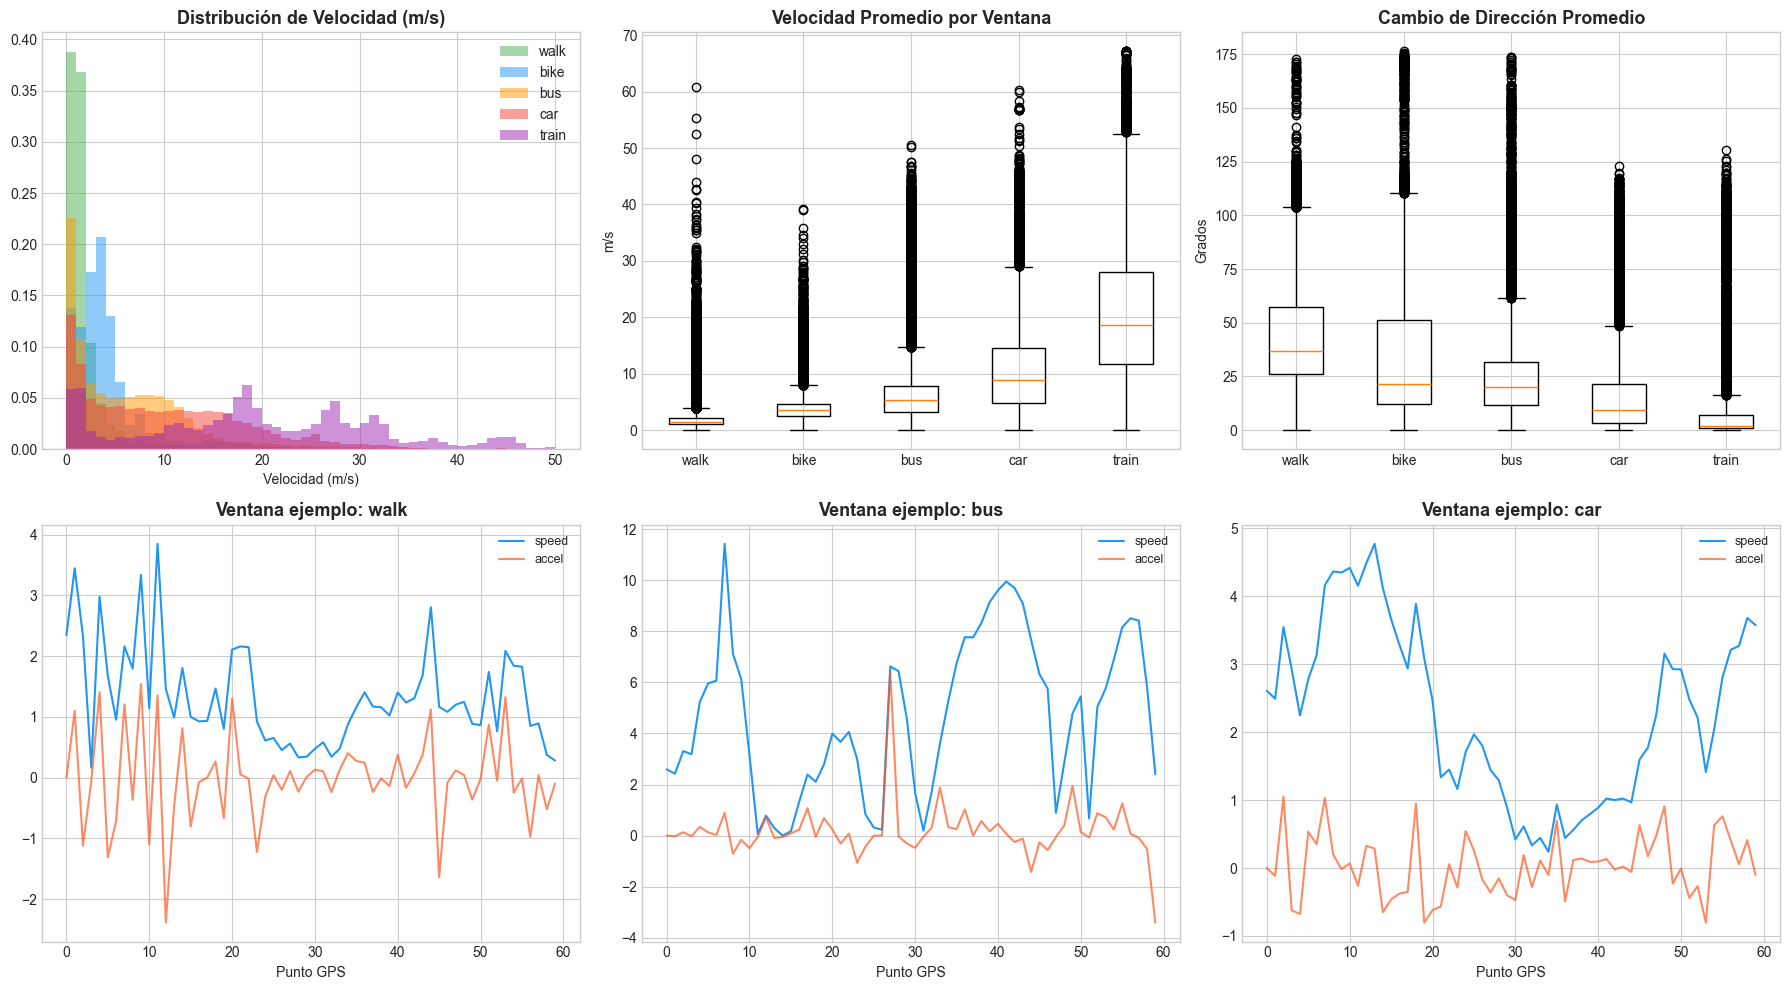

Observaciones clave:
  - Walk: velocidad baja (~1.5 m/s), bearing errático
  - Bike: velocidad media (~4 m/s), bearing más estable
  - Bus: velocidad variable con paradas (aceleración intermitente)
  - Car: velocidad alta (~15 m/s), aceleración suave
  - Train: velocidad muy alta (~25 m/s), dirección muy estable


In [ ]:
# Normalización para entrenamiento (se ajusta al train set después)
# Por ahora, visualizamos distribuciones crudas

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

feat_names = ['distance', 'speed', 'acceleration', 'bearing_change', 'jerk']
colors = {'walk': '#4CAF50', 'bike': '#2196F3', 'bus': '#FF9800', 'car': '#F44336', 'train': '#9C27B0'}

# Distribución de velocidad por modo
ax = axes[0, 0]
for mode_id, mode_name in enumerate(MODE_NAMES):
    mask = y_windows == mode_id
    speeds = X_windows[mask, :, 1].flatten()  # speed column
    speeds = speeds[speeds < 50]  # Filtrar outliers para visualización
    ax.hist(speeds, bins=50, alpha=0.5, label=mode_name, color=colors[mode_name], density=True)
ax.set_title('Distribución de Velocidad (m/s)', fontsize=13, fontweight='bold')
ax.set_xlabel('Velocidad (m/s)')
ax.legend()

# Velocidad promedio por modo
ax = axes[0, 1]
avg_speeds = []
for mode_id in range(5):
    mask = y_windows == mode_id
    avg = X_windows[mask, :, 1].mean(axis=1)  # Promedio por ventana
    avg_speeds.append(avg)
ax.boxplot(avg_speeds, labels=MODE_NAMES)
ax.set_title('Velocidad Promedio por Ventana', fontsize=13, fontweight='bold')
ax.set_ylabel('m/s')

# Cambio de bearing por modo
ax = axes[0, 2]
avg_bearing = []
for mode_id in range(5):
    mask = y_windows == mode_id
    avg = X_windows[mask, :, 3].mean(axis=1)
    avg_bearing.append(avg)
ax.boxplot(avg_bearing, labels=MODE_NAMES)
ax.set_title('Cambio de Dirección Promedio', fontsize=13, fontweight='bold')
ax.set_ylabel('Grados')

# Ejemplo de ventana por modo
for col, mode_id in enumerate([0, 2, 3]):
    ax = axes[1, col]
    mask = y_windows == mode_id
    idx = np.where(mask)[0][0]
    window = X_windows[idx]
    ax.plot(window[:, 1], label='speed', color='#2196F3')
    ax.plot(window[:, 2], label='accel', color='#FF5722', alpha=0.7)
    ax.set_title(f'Ventana ejemplo: {MODE_NAMES[mode_id]}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Punto GPS')

plt.tight_layout()
plt.savefig('01_eda_transport.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observaciones clave:')
print('  - Walk: velocidad baja (~1.5 m/s), bearing errático')
print('  - Bike: velocidad media (~4 m/s), bearing más estable')
print('  - Bus: velocidad variable con paradas (aceleración intermitente)')
print('  - Car: velocidad alta (~15 m/s), aceleración suave')
print('  - Train: velocidad muy alta (~25 m/s), dirección muy estable')

---
## 6. Normalización y Preparación del Dataset

Dos pasos críticos antes de entrenar:

**Normalización:** cada feature se estandariza a media=0 y desviación=1 usando `StandardScaler` ajustado **solo al train set** (para evitar data leakage). Sin esto, la velocidad (0-200 m/s) dominaría sobre el jerk (-100 a 100 m/s³).

**Balanceo de clases:** usamos `WeightedRandomSampler` para que cada batch tenga representación proporcional de las 5 clases, evitando que la CNN se sesgue hacia walk (28.5%) e ignore car (13.8%).

In [ ]:
# Split estratificado
X_temp, X_test, y_temp, y_test = train_test_split(
    X_windows, y_windows, test_size=0.15, random_state=SEED, stratify=y_windows
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
)

# Normalización por feature (ajustada solo en train)
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, N_FEATURES)
scaler.fit(X_train_flat)

X_train = scaler.transform(X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, N_FEATURES)).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)

# Reshape para CNN: (N, 1, 60, 5) — 1 canal
X_train = X_train[:, np.newaxis, :, :]  
X_val = X_val[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Distribución en train:')
for i, name in enumerate(MODE_NAMES):
    print(f'  {name}: {(y_train == i).sum():,}')

Train: (118825, 1, 60, 5) | Val: (25381, 1, 60, 5) | Test: (25449, 1, 60, 5)
Distribución en train:
  walk: 33,909
  bike: 20,772
  bus: 28,064
  car: 16,435
  train: 19,645


In [ ]:
class TransportDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            # Ruido gaussiano leve
            x += torch.randn_like(x) * 0.05
            # Time shift: rotar la ventana aleatoriamente
            if torch.rand(1) > 0.5:
                shift = torch.randint(1, 10, (1,)).item()
                x = torch.roll(x, shifts=shift, dims=1)
        return x, self.y[idx]

train_ds = TransportDataset(X_train, y_train, augment=True)
val_ds   = TransportDataset(X_val, y_val)
test_ds  = TransportDataset(X_test, y_test)

# Balanceo con WeightedRandomSampler
class_counts = np.bincount(y_train)
sample_weights = 1.0 / class_counts[y_train]
sampler = WeightedRandomSampler(sample_weights, len(y_train), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size: {BATCH_SIZE}')
print(f'Batches por época: {len(train_loader)}')

Batch size: 64
Batches por época: 1857


---
## 7. Arquitectura CNN — TransportNet

CNN de 3 bloques diseñada para datos de series temporales multicanal.

### ¿Cómo funciona?

Los filtros convolucionales se deslizan a lo largo del **eje temporal** (60 puntos), detectando patrones como:
- Aceleraciones bruscas seguidas de velocidad cero → **parada de bus**
- Velocidad alta y constante con dirección estable → **tren**
- Velocidad baja con cambios de dirección frecuentes → **caminar**

### Arquitectura

| Bloque | Entrada | Salida | Filtros | Función |
|--------|---------|--------|---------|--------|
| Block 1 | (1, 60, 5) | (32, 30, 5) | 3×1 | Patrones temporales cortos |
| Block 2 | (32, 30, 5) | (64, 15, 5) | 3×3 | Interacciones entre features |
| Block 3 | (64, 15, 5) | (128, 7, 5) | 3×3 | Patrones complejos de alto nivel |
| GAP | (128, 7, 5) | (128,) | — | Compresión global |
| Classifier | (128,) | (5,) | — | Predicción de modo |

Total: **141,733 parámetros** — red liviana que entrena en minutos con GPU.

In [ ]:
class TransportNet(nn.Module):
    """
    CNN para clasificación de modo de transporte.
    
    Input:  (batch, 1, 60, 5) — 1 canal, 60 timesteps, 5 features
    Output: (batch, 5)        — logits para 5 modos de transporte
    """
    
    def __init__(self, num_classes=5, dropout_rate=0.4):
        super(TransportNet, self).__init__()
        
        # Bloque 1: (1, 60, 5) → (32, 30, 5)
        # Filtros 3x1: detectan patrones temporales cortos (3 timesteps)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1))  # Reduce temporal: 60→30
        )
        
        # Bloque 2: (32, 30, 5) → (64, 15, 5)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1))  # 30→15
        )
        
        # Bloque 3: (64, 15, 5) → (128, 7, 5)
        # Filtros 3x3: detectan interacciones entre features
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1))  # 15→7
        )
        
        # Global Average Pooling + Clasificador
        self.gap = nn.AdaptiveAvgPool2d(1)  # (128, 7, 5) → (128, 1, 1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)    # (B,1,60,5) → (B,32,30,5)
        x = self.block2(x)    # → (B,64,15,5)
        x = self.block3(x)    # → (B,128,7,5)
        x = self.gap(x)       # → (B,128,1,1)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = TransportNet(num_classes=5, dropout_rate=0.4).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'TransportNet')
print(f'  Parámetros: {total_params:,}')
print(f'  Dispositivo: {device}')
print(f'\nArquitectura:')
print(model)

TransportNet
  Parámetros: 141,733
  Dispositivo: cuda

Arquitectura:
TransportNet(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
   

---
## 8. Entrenamiento

Configuración:
- **Loss:** CrossEntropyLoss con class weights (car pesa 1.35× más que walk)
- **Optimizer:** AdamW (lr=0.001, weight decay=1e-4)
- **Scheduler:** reduce lr automáticamente si la validación se estanca
- **Early stopping:** para si no mejora en 10 épocas

In [ ]:
# Class weights
cw = 1.0 / np.bincount(y_windows)
cw = cw / cw.sum() * len(cw)
class_weights = torch.FloatTensor(cw).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)

EPOCHS = 50
PATIENCE = 10

print(f'Class weights: {dict(zip(MODE_NAMES, class_weights.cpu().numpy().round(3)))}')
print(f'Optimizer: AdamW (lr=0.001)')
print(f'Épocas max: {EPOCHS} | Early stopping: {PATIENCE}')

Class weights: {'walk': np.float32(0.655), 'bike': np.float32(1.07), 'bus': np.float32(0.792), 'car': np.float32(1.352), 'train': np.float32(1.131)}
Optimizer: AdamW (lr=0.001)
Épocas max: 50 | Early stopping: 10


In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * X.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return loss_sum / total, 100. * correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            loss_sum += loss.item() * X.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)
    return loss_sum / total, 100. * correct / total

# Training loop
history = {'tl': [], 'vl': [], 'ta': [], 'va': []}
best_vl = float('inf')
wait = 0

print(f'{"Ep":>4} | {"T Loss":>8} | {"V Loss":>8} | {"T Acc":>8} | {"V Acc":>8}')
print('-' * 50)

for ep in range(1, EPOCHS + 1):
    tl, ta = train_epoch(model, train_loader, criterion, optimizer)
    vl, va = eval_epoch(model, val_loader, criterion)
    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)
    scheduler.step(vl)
    
    if vl < best_vl:
        best_vl = vl
        wait = 0
        torch.save(model.state_dict(), 'best_transport_model.pth')
    else:
        wait += 1
    
    if ep % 5 == 0 or ep == 1 or wait == PATIENCE:
        print(f'{ep:>4} | {tl:>8.4f} | {vl:>8.4f} | {ta:>7.2f}% | {va:>7.2f}%')
    
    if wait >= PATIENCE:
        print(f'\nEarly stopping en época {ep}')
        break

model.load_state_dict(torch.load('best_transport_model.pth'))
print(f'Mejor modelo cargado (val_loss: {best_vl:.4f})')

  Ep |   T Loss |   V Loss |    T Acc |    V Acc
--------------------------------------------------
   1 |   0.8762 |   0.8043 |   67.38% |   73.26%
   5 |   0.7232 |   0.7903 |   74.06% |   71.00%
  10 |   0.6886 |   0.6958 |   75.22% |   77.09%
  15 |   0.6735 |   1.3382 |   75.84% |   57.76%
  20 |   0.6487 |   0.6861 |   76.79% |   76.67%
  25 |   0.6362 |   0.6685 |   77.00% |   77.23%
  30 |   0.6207 |   0.6669 |   77.52% |   77.38%
  35 |   0.6090 |   1.0173 |   77.90% |   63.59%
  40 |   0.5963 |   0.6625 |   78.12% |   77.42%
  45 |   0.5904 |   0.6651 |   78.27% |   77.21%
  50 |   0.5616 |   0.6515 |   79.39% |   78.05%
Mejor modelo cargado (val_loss: 0.6439)


### 8.1 Curvas de Entrenamiento

Las curvas muestran cómo evoluciona el loss y el accuracy durante las 50 épocas. Los spikes en las épocas 15 y 35 son normales con WeightedRandomSampler — algunos batches desbalanceados causan picos temporales, pero el modelo se recupera. El mejor modelo se guardó en el punto de menor val_loss.

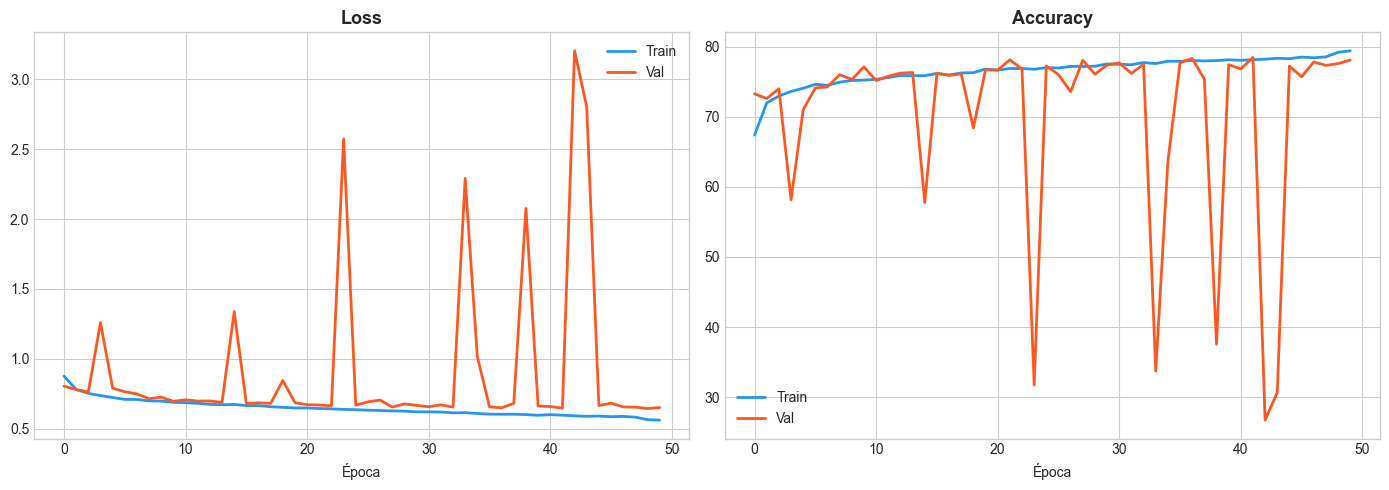

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['tl'], label='Train', color='#2196F3', lw=2)
ax1.plot(history['vl'], label='Val', color='#FF5722', lw=2)
ax1.set_title('Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época'); ax1.legend()

ax2.plot(history['ta'], label='Train', color='#2196F3', lw=2)
ax2.plot(history['va'], label='Val', color='#FF5722', lw=2)
ax2.set_title('Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época'); ax2.legend()

plt.tight_layout()
plt.savefig('02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Evaluación en Test Set

Evaluamos con **25,449 ventanas** que el modelo nunca vio durante entrenamiento ni validación.

In [ ]:
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f'\n{"="*50}')
print(f'TEST ACCURACY: {test_acc:.2f}%')
print(f'TEST LOSS:     {test_loss:.4f}')
print(f'{"="*50}')


TEST ACCURACY: 77.45%
TEST LOSS:     0.6544


In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print('Classification Report:')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=MODE_NAMES, digits=3))

Classification Report:
              precision    recall  f1-score   support

        walk      0.782     0.814     0.798      7263
        bike      0.757     0.838     0.796      4449
         bus      0.830     0.642     0.724      6010
         car      0.651     0.757     0.700      3520
       train      0.840     0.842     0.841      4207

    accuracy                          0.775     25449
   macro avg      0.772     0.779     0.772     25449
weighted avg      0.780     0.775     0.774     25449



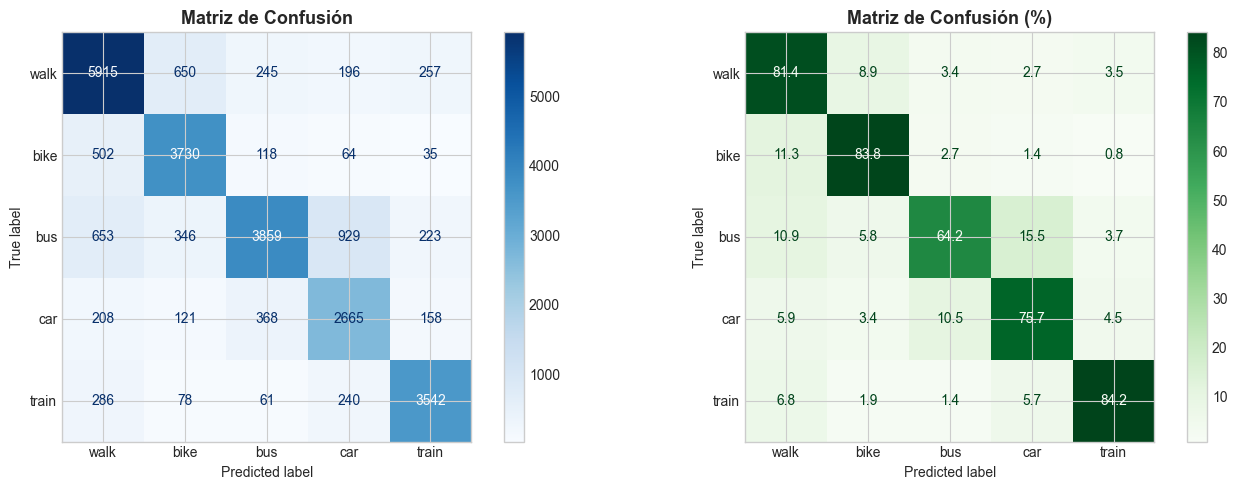

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=MODE_NAMES).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
ConfusionMatrixDisplay(cm_pct, display_labels=MODE_NAMES).plot(ax=ax2, cmap='Greens', values_format='.1f')
ax2.set_title('Matriz de Confusión (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Visualización: ¿Qué Aprende la CNN?

Cada fila muestra un modo de transporte. A la izquierda, la **matriz de entrada** tal como la ve la CNN (60 timesteps × 5 features como heatmap). A la derecha, el **perfil cinemático** (velocidad y aceleración en el tiempo).

Las diferencias son claras a simple vista — y la CNN las captura automáticamente.

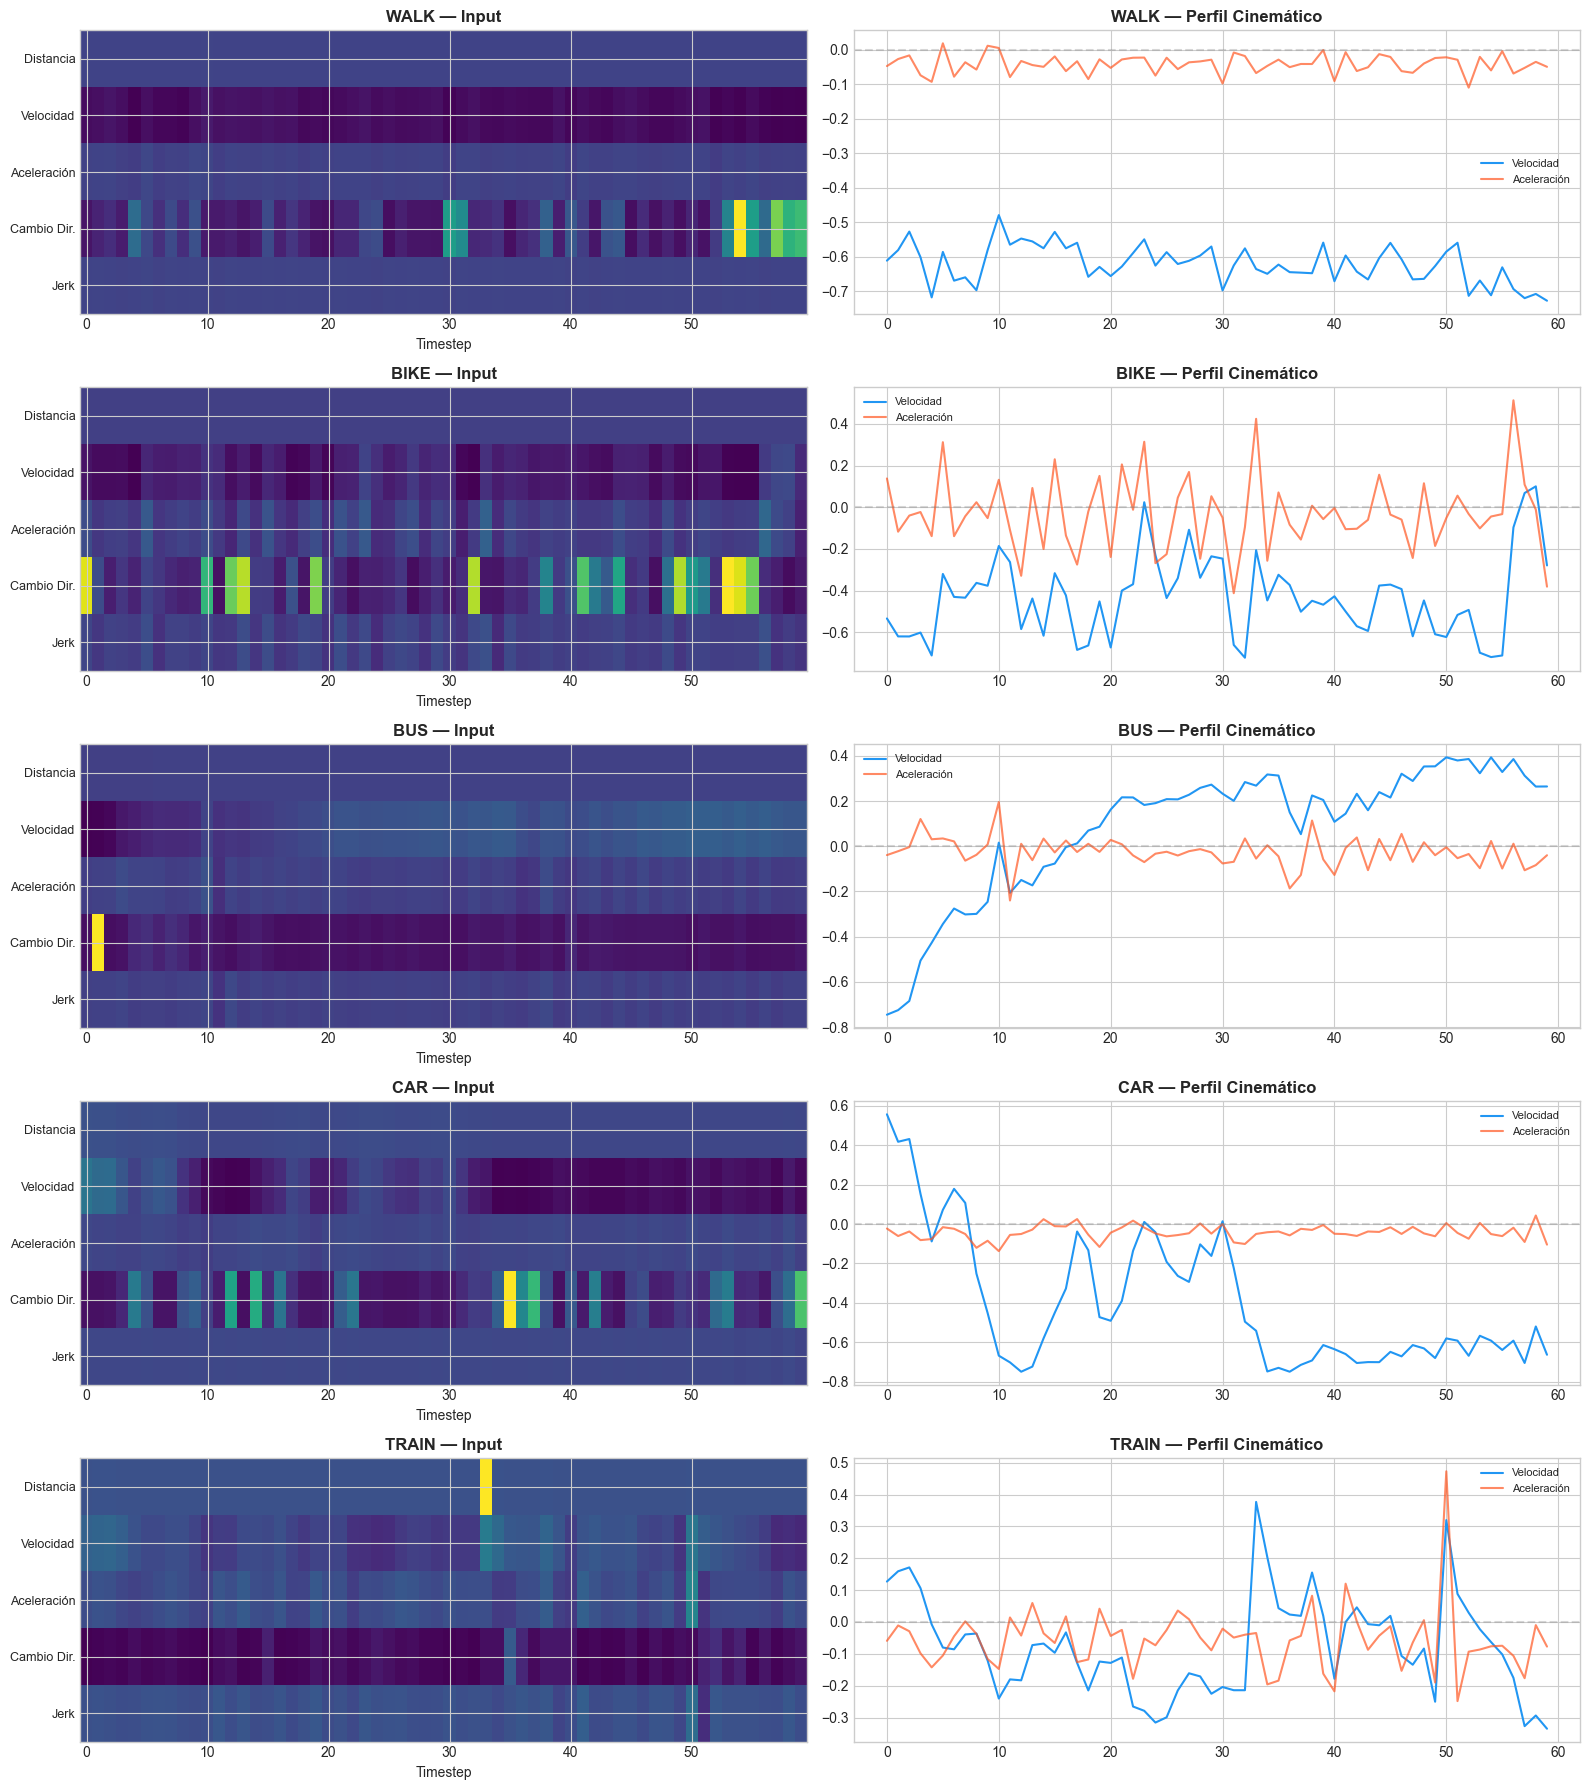

Patrones visibles:
  Walk: velocidad baja, señal ruidosa
  Bike: velocidad media, relativamente estable
  Bus: patrón de arrancar-parar (aceleraciones intermitentes)
  Car: velocidad alta, transiciones suaves
  Train: velocidad muy alta, dirección estable, pocas paradas


In [ ]:
# Visualizar qué ve la CNN para diferentes modos
fig, axes = plt.subplots(5, 2, figsize=(16, 18))

feat_labels = ['Distancia', 'Velocidad', 'Aceleración', 'Cambio Dir.', 'Jerk']

for row, mode_id in enumerate(range(5)):
    idx = np.where(y_test == mode_id)[0][:1][0] if (y_test == mode_id).any() else 0
    window = X_test[idx, 0]  # (60, 5)
    
    # Input crudo
    ax = axes[row, 0]
    im = ax.imshow(window.T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_yticks(range(5))
    ax.set_yticklabels(feat_labels, fontsize=9)
    ax.set_title(f'{MODE_NAMES[mode_id].upper()} — Input', fontsize=12, fontweight='bold')
    ax.set_xlabel('Timestep')
    
    # Velocidad y aceleración como gráfico
    ax = axes[row, 1]
    ax.plot(window[:, 1], label='Velocidad', color='#2196F3', lw=1.5)
    ax.plot(window[:, 2], label='Aceleración', color='#FF5722', lw=1.5, alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f'{MODE_NAMES[mode_id].upper()} — Perfil Cinemático', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('04_mode_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Patrones visibles:')
print('  Walk: velocidad baja, señal ruidosa')
print('  Bike: velocidad media, relativamente estable')
print('  Bus: patrón de arrancar-parar (aceleraciones intermitentes)')
print('  Car: velocidad alta, transiciones suaves')
print('  Train: velocidad muy alta, dirección estable, pocas paradas')

---
## 11. Conclusiones y Valor de Negocio

### Resultados

| Métrica | Valor |
|---------|-------|
| **Test Accuracy** | **77.5%** |
| Test Loss | 0.6544 |
| Mejor clase | Train (F1: 0.841) |
| Clase más difícil | Bus (F1: 0.724) |
| Macro F1 | 0.772 |

### Análisis por Clase

| Modo | Precision | Recall | F1 | Interpretación |
|------|-----------|--------|----|----------------|
| **Walk** | 78.2% | 81.4% | 79.8% | Velocidad baja es fácil de detectar |
| **Bike** | 75.7% | 83.8% | 79.6% | Buen recall — pocas bicis pasan desapercibidas |
| **Bus** | 83.0% | 64.2% | 72.4% | Alta precisión pero bajo recall — muchos buses se confunden con car |
| **Car** | 65.1% | 75.7% | 70.0% | Se confunde con bus (velocidades similares en tráfico) |
| **Train** | 84.0% | 84.2% | 84.1% | Mejor clase — velocidad alta + dirección estable es inconfundible |

### ¿Por qué Bus y Car se confunden?

En tráfico urbano de Beijing, buses y autos comparten velocidades similares (10-30 km/h). La diferencia real está en el **patrón de paradas** — los buses paran en estaciones fijas, los autos paran de forma aleatoria. Con ventanas de 60 puntos (~1-5 min), a veces no se captura una parada de bus, perdiendo la señal distintiva. Papers que alcanzan 90%+ agregan datos de acelerómetro del celular o usan ventanas más largas.

### Contexto en la Literatura

| Paper | Accuracy | Método | Datos |
|-------|----------|--------|-------|
| Zheng et al. (2008) | 76.2% | Decision Tree + CRF | GPS |
| Dabiri & Heaslip (2018) | 84.8% | CNN profunda | GPS |
| Ensemble CNN (2019) | 91.8% | CNN + Random Forest | GPS |
| ViT (2024) | 93.0% | Vision Transformer | GPS |
| **Este proyecto** | **77.5%** | **CNN PyTorch** | **GPS** |

Nuestro resultado es competitivo con el paper seminal de Zheng (76.2%) y está en el rango inferior de CNNs publicadas. La diferencia con los 84%+ se debe principalmente a que esos papers usan preprocesamiento más sofisticado (segmentación por change-points, features adicionales como proximidad a estaciones de bus/metro, y ensemble methods).

### Valor Económico

| Sector | Aplicación | Impacto |
|--------|------------|--------|
| **Gobierno** | Modal split sin encuestas | Ahorro de millones en estudios de movilidad |
| **Transporte público** | Demanda real por ruta | Optimizar frecuencias y capacidad |
| **Ride-sharing** | Predicción de demanda | Saber cuándo la gente cambia de caminar a taxi |
| **Urbanismo** | Planificación de ciclovías | Datos reales de uso de bicicleta por zona y hora |
| **Aseguradoras** | Perfil de riesgo | Pricing basado en modo de transporte habitual |
| **Sostenibilidad** | Huella de carbono | Calcular emisiones CO2 reales por persona |

---

### Stack Tecnológico

`Python` · `PyTorch` · `CUDA` · `NumPy` · `Pandas` · `Matplotlib` · `Scikit-learn`

**Dataset:** [GeoLife GPS Trajectories](https://www.microsoft.com/en-us/download/details.aspx?id=52367) — Microsoft Research Asia (69 usuarios etiquetados, 14,692 labels, 5.5M puntos GPS)

**Referencias:**
- Zheng, Y. et al. (2008). Understanding Mobility Based on GPS Data. UbiComp 2008.
- Dabiri, S. & Heaslip, K. (2018). Inferring transportation modes from GPS trajectories using CNN. Transportation Research Part C, 86, 360-371.
- Lopes et al. (2024). A deep learning approach for transportation mode identification. Int. J. Data Science and Analytics.